<a href="https://colab.research.google.com/github/harini-3005/Oasis-Infobyte-task-2/blob/main/task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving ifood_df.csv to ifood_df.csv
    Income  Kidhome  Teenhome  Recency  MntWines  MntFruits  MntMeatProducts  \
0  58138.0        0         0       58       635         88              546   
1  46344.0        1         1       38        11          1                6   
2  71613.0        0         0       26       426         49              127   
3  26646.0        1         0       26        11          4               20   
4  58293.0        1         0       94       173         43              118   

   MntFishProducts  MntSweetProducts  MntGoldProds  ...  marital_Together  \
0              172                88            88  ...                 0   
1                2                 1             6  ...                 0   
2              111                21            42  ...                 1   
3               10                 3             5  ...                 1   
4               46                27            15  ...                 0   

   marital_Widow  ed

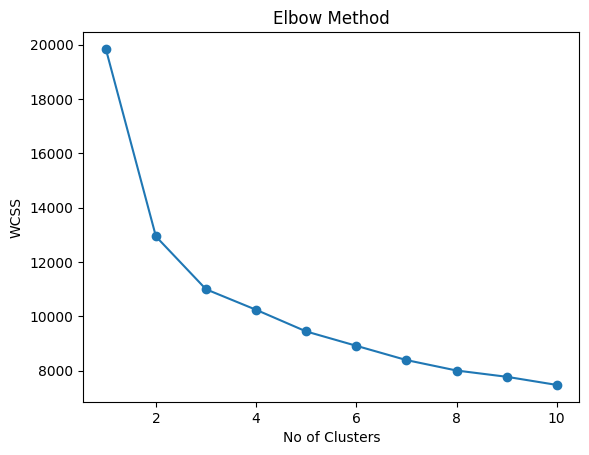

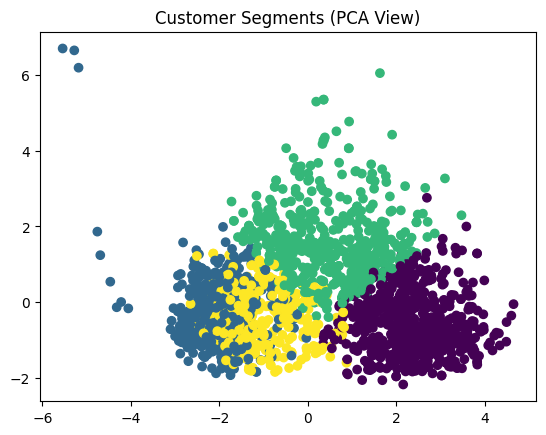


Cluster Summary:
               Income    Recency        Age     MntTotal  NumWebPurchases  \
Cluster                                                                     
0        74860.655068  49.698941  52.298033  1240.615734         5.128593   
1        30307.536661  45.120125  42.176287    69.522621         2.062402   
2        55759.964356  47.611881  53.944554   651.887129         6.867327   
3        42105.309045  55.899497  59.849246   118.296482         2.165829   

         NumCatalogPurchases  NumStorePurchases  NumDealsPurchases  \
Cluster                                                              
0                   5.794251           8.493192           1.317700   
1                   0.468019           3.004680           1.989080   
2                   2.720792           7.497030           4.382178   
3                   0.826633           3.806533           1.891960   

         NumWebVisitsMonth  
Cluster                     
0                 2.909228  
1          

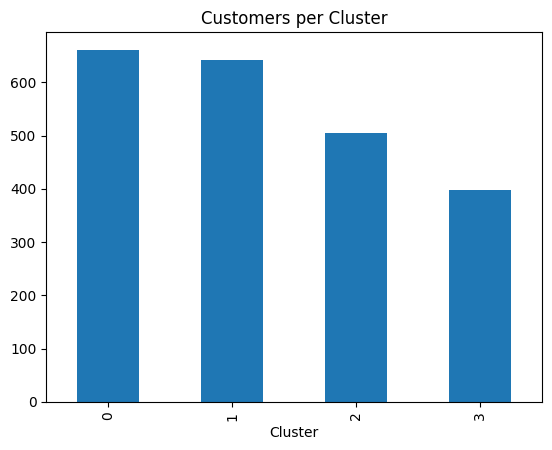


Segmentation Completed Successfully!


In [ ]:
# =====================================
# CUSTOMER SEGMENTATION USING K-MEANS
# =====================================

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 2. Upload Dataset
from google.colab import files
uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])

# 3. Explore Data
print(df.head())
print(df.info())
print(df.isnull().sum())

# 4. Data Cleaning
df.fillna(df.median(numeric_only=True), inplace=True)

# 5. Feature Selection for Clustering
features = [
    'Income','Recency','Age','MntTotal',
    'NumWebPurchases','NumCatalogPurchases','NumStorePurchases',
    'NumDealsPurchases','NumWebVisitsMonth'
]

X = df[features]

# 6. Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =====================================
# 📉 FIND OPTIMAL CLUSTERS (ELBOW)
# =====================================
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("No of Clusters")
plt.ylabel("WCSS")
plt.show()

# 7. Apply K-Means (Assume 4 clusters)
kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# =====================================
# 📊 VISUALIZATION
# =====================================

# 8. PCA for 2D Visualization
pca = PCA(n_components=2)
pca_comp = pca.fit_transform(X_scaled)

plt.figure()
plt.scatter(pca_comp[:,0], pca_comp[:,1], c=df['Cluster'])
plt.title("Customer Segments (PCA View)")
plt.show()

# 9. Cluster Characteristics
cluster_summary = df.groupby('Cluster')[features].mean()
print("\nCluster Summary:")
print(cluster_summary)

# 10. Cluster Count
plt.figure()
df['Cluster'].value_counts().plot(kind='bar')
plt.title("Customers per Cluster")
plt.show()

print("\nSegmentation Completed Successfully!")
